In [80]:
# !pip install pyreadstat
# !pip install numpy
# !pip install tensorflow
# !pip install pyreadstat
# !pip install tensorflow.python

### Ensuring reproducibility

In [81]:
import os
import random
import numpy as np
import tensorflow as tf

def set_seed(seed=42):
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)         # Python hash seed
    random.seed(seed)                                # Python random module
    np.random.seed(seed)                             # NumPy
    tf.random.set_seed(seed)                         # TensorFlow
    tf.keras.utils.set_random_seed(seed)             # For keras randomness
    tf.config.experimental.enable_op_determinism()   # Make ops deterministic

# Call this before training
set_seed(42)


### Libraries

In [82]:
import pyreadstat
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, recall_score, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from collections import Counter
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
import keras_tuner as kt
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import Recall
from keras_tuner import HyperModel, RandomSearch

# Explanotary Data Analysis

In [83]:
# df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0]                #Kaggle dataset
# df_ch = pyreadstat.read_sav('/workspaces/malnutrition/Dataset/ch.sav')[0]          #GitHub Codespace dataset
df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0]      #Local dataset

# Renaming the columns
feature_coded = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = feature_coded.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Drop missing values
df2 = df1.copy()
df2.dropna(inplace=True)

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})

# Standardize continuous feature
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

# One-hot encode to nominal features
df2 = pd.get_dummies(df2, columns=['province'], drop_first=True)

# Convert only boolean dummy features to 0/1
cols_to_convert = df2.columns.difference(['child_weight'])
df2[cols_to_convert] = df2[cols_to_convert].astype(int)
df2.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-0.617934,1,0,0,0,1,5,0,1,1,0,0,0,0,0,0
2,2,0.797956,1,1,0,0,0,2,0,1,0,0,0,0,0,0,0


### Train-test Split

In [84]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# We want 15% of total data as validation, which is 15 / 80 = 0.1875 of the temp set
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1875, stratify=y_temp, random_state=42)

# Artificial Neural Network

### Base model

In [85]:
# Define model architecture
ann_base = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
])

# Compile model
ann_base.compile(
    optimizer=Adam(learning_rate=0.005),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall(name='recall')]
)

# Early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = ann_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    shuffle=True,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
146/146 [==============================] - 1s 3ms/step - loss: 0.6722 - accuracy: 0.5965 - recall: 0.4735 - val_loss: 0.6240 - val_accuracy: 0.6592 - val_recall: 0.6695
Epoch 2/100
146/146 [==============================] - 0s 2ms/step - loss: 0.6255 - accuracy: 0.6670 - recall: 0.5689 - val_loss: 0.5950 - val_accuracy: 0.6965 - val_recall: 0.5690
Epoch 3/100
146/146 [==============================] - 0s 1ms/step - loss: 0.6071 - accuracy: 0.6854 - recall: 0.5545 - val_loss: 0.5706 - val_accuracy: 0.7337 - val_recall: 0.6402
Epoch 4/100
146/146 [==============================] - 0s 1ms/step - loss: 0.5945 - accuracy: 0.6914 - recall: 0.5738 - val_loss: 0.5616 - val_accuracy: 0.7169 - val_recall: 0.6234
Epoch 5/100
146/146 [==============================] - 0s 1ms/step - loss: 0.5852 - accuracy: 0.6902 - recall: 0.5728 - val_loss: 0.5723 - val_accuracy: 0.7058 - val_recall: 0.4979
Epoch 6/100
146/146 [==============================] - 0s 1ms/step - loss: 0.5781 - accuracy: 0

### For better accuracy but has less recall

In [86]:
# # Define model architecture
# model_simple = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#     Dropout(0.3),
#     Dense(32, activation='relu'),
#     Dropout(0.2),
#     Dense(1, activation='sigmoid')  # Use sigmoid for binary classification
# ])

# # Compile model
# model_simple.compile(
#     optimizer=Adam(learning_rate=0.005),
#     loss='binary_crossentropy',
#     metrics=['accuracy', 'recall']
# )

# # Early stopping to avoid overfitting
# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Fit the model
# history = model_simple.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),
#     shuffle=True,
#     epochs=100,
#     batch_size=16,
#     callbacks=[early_stop],
#     verbose=1
# )

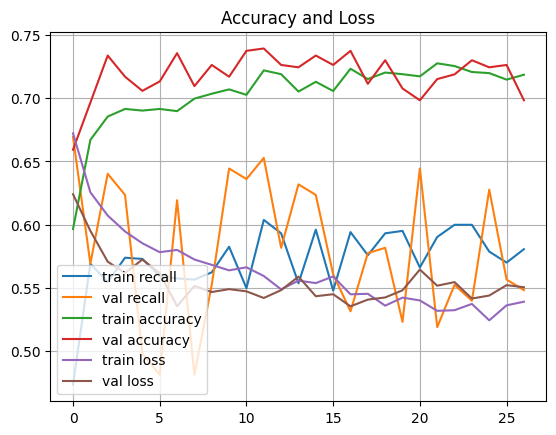

In [87]:
# Accuracies and losses
plt.plot(history.history['recall'], label='train recall')
plt.plot(history.history['val_recall'], label='val recall')
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.grid()
plt.title('Accuracy and Loss')
plt.show()

The training and validation curves in the plot indicate that the model is learning effectively, with both training and validation accuracy steadily improving and converging around 0.72. The training and validation loss curves also show expected behavior, with the training loss decreasing smoothly and validation loss initially dropping before slightly rising, suggesting a mild risk of overfitting after around 20 epochs. The recall on the training set gradually improves, indicating the model is increasingly successful at identifying malnourished children during training. However, the validation recall fluctuates significantly across epochs, which may point to model adjustments.

In [88]:
y_pred = (ann_base.predict(X_test) > 0.5).astype("int")
print(classification_report(y_test, y_pred))

23/23 [==============================] - 0s 950us/step
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       397
           1       0.76      0.55      0.64       320

    accuracy                           0.72       717
   macro avg       0.73      0.70      0.70       717
weighted avg       0.73      0.72      0.71       717



In [89]:
# Use model.predict() and flatten to 1D
# y_probas = ann_base.predict(X_test).ravel()

# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_pred)}')

Average Precision: 0.6165307626473945


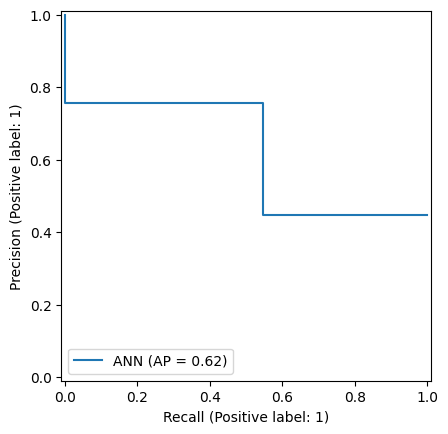

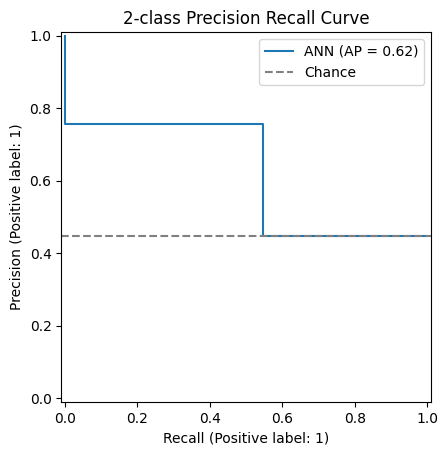

In [90]:
# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()

# Hyperparameter Tuning

In [91]:
# Define a model builder function
def build_model(hp):
    ann = Sequential()

    # Add input layer
    ann.add(Input(shape=(X_train.shape[1],)))

    # First dense layer: tune number of neurons and dropout
    ann.add(Dense(
        hp.Int('units_1', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    ann.add(Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)))

    # Second dense layer
    ann.add(Dense(
        hp.Int('units_2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    ann.add(Dropout(hp.Float('dropout_2', 0.1, 0.3, step=0.1)))

    # Output layer
    ann.add(Dense(1, activation='sigmoid'))

    # Compile with tunable learning rate
    ann.compile(
        optimizer=Adam(hp.Choice('learning_rate', [0.001, 0.0005, 0.005])),
        loss='binary_crossentropy',
        metrics=['accuracy', Recall()]
    )

    return ann

In [92]:
# Define tuner
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_recall", direction="max"),  # Focus on recall
    max_trials=5,
    executions_per_trial=1,
    overwrite=True,
    directory='kt_dir',
    project_name='malnutrition_tuning'
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Run the search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Trial 5 Complete [00h 00m 13s]
val_recall: 0.73221755027771

Best val_recall So Far: 0.73221755027771
Total elapsed time: 00h 00m 53s


In [93]:
ann_tuned = tuner.get_best_models(1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

# Re-compile the best model before using it
ann_tuned.compile(
    optimizer=Adam(learning_rate=best_hps.get('learning_rate')),
    loss='binary_crossentropy',
    metrics=['accuracy', Recall()]
)

In [94]:

# Evaluate or predict
y_pred_tuned = (ann_tuned.predict(X_test) > 0.5).astype("int")

print("Classification Report:\n", classification_report(y_test, y_pred_tuned))

23/23 [==============================] - 0s 772us/step
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.66      0.72       397
           1       0.65      0.77      0.70       320

    accuracy                           0.71       717
   macro avg       0.71      0.72      0.71       717
weighted avg       0.72      0.71      0.71       717



In [95]:
print("Best Hyperparameters:")
print(f"units_1: {best_hps.get('units_1')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")

Best Hyperparameters:
units_1: 96
dropout_1: 0.30000000000000004
units_2: 32
dropout_2: 0.2
learning_rate: 0.0005


23/23 [==============================] - 0s 732us/step


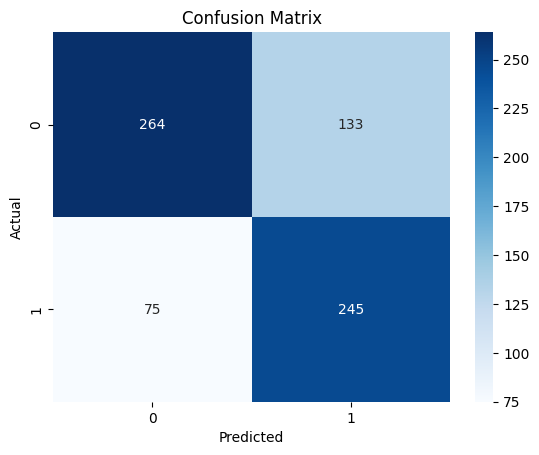

In [96]:
# Predict classes
y_prob = ann_tuned.predict(X_test)
# y_pred = (y_prob > 0.5).astype(int).reshape(-1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

23/23 [==============================] - 0s 1ms/step


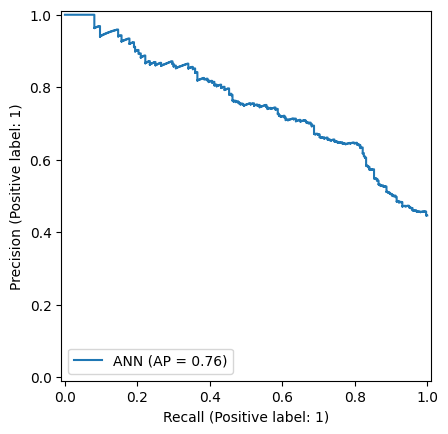

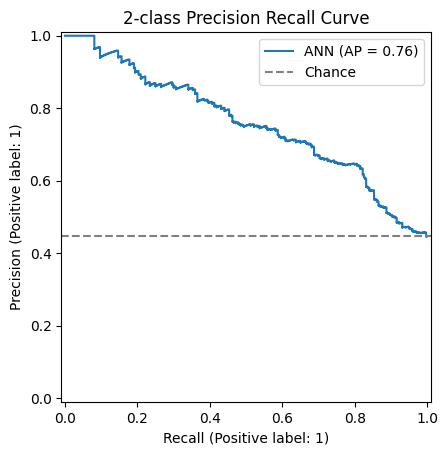

In [97]:
# Get predicted probabilities
y_probas = ann_tuned.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()